# Exploratory Data Analysis (EDA): Predicting Household Savings Behavior in Nigeria

This notebook performs a comprehensive EDA on the household dataset to understand the drivers of savings behavior in Nigeria. The goal is to prepare the data for supervised machine learning classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Load dataset
df = pd.read_csv('13_master_household_ml_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (4771, 42)


In [2]:
# Basic Overview
display(df.info())
display(df.describe(include='all'))
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4771 entries, 0 to 4770
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   hhid                              4771 non-null   int64  
 1   eligible_members                  4771 non-null   int64  
 2   formal_savers                     4771 non-null   int64  
 3   informal_savers                   4771 non-null   int64  
 4   savings_responses                 4771 non-null   int64  
 5   savings_answered                  4771 non-null   int64  
 6   savings_target                    4771 non-null   int64  
 7   bank_access_count                 4771 non-null   int64  
 8   mobile_money_access_count         4771 non-null   int64  
 9   assisted_banking_count            4771 non-null   int64  
 10  any_bank_access                   4771 non-null   int64  
 11  any_mobile_money_access           4771 non-null   int64  
 12  any_as

None

,hhid,eligible_members,formal_savers,informal_savers,savings_responses,savings_answered,savings_target,bank_access_count,mobile_money_access_count,assisted_banking_count,...,internet_access_count,any_mobile_access,any_internet_access,asset_items_listed,asset_types_owned,total_units_owned,total_current_asset_value,income_source_types_listed,income_source_types_received,total_reported_income_sources
count,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,4771.000000,...,4771.000000,4771.000000,4771.000000,4771.0,4771.000000,4771.000000,4.771000e+03,4771.0,4771.000000,4.771000e+03
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,173134.914693,3.477258,0.809055,0.729197,3.477258,3.477049,0.548522,1.337875,1.002934,0.862293,...,1.097254,0.932719,0.460071,42.0,7.728568,40.002934,3.263792e+05,7.0,0.280444,5.021469e+04
std,105649.775967,2.055737,1.215126,1.195916,2.055737,2.055837,0.497692,1.474120,1.456134,1.366761,...,1.657261,0.250535,0.498455,0.0,4.514581,1737.413818,7.288833e+05,0.0,0.576035,5.049471e+05
min,10001.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,42.0,0.000000,0.000000,0.000000e+00,7.0,0.000000,0.000000e+00
25%,79032.500000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,42.0,4.000000,8.000000,4.100000e+04,7.0,0.000000,0.000000e+00
50%,169111.000000,3.000000,0.000000,0.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,42.0,7.000000,13.000000,1.130000e+05,7.0,0.000000,0.000000e+00
75%,249241.500000,4.000000,1.000000,1.000000,4.000000,4.000000,1.000000,2.000000,2.000000,1.000000,...,2.000000,1.000000,1.000000,42.0,10.000000,19.000000,3.004500e+05,7.0,0.000000,0.000000e+00


,hhid,eligible_members,formal_savers,informal_savers,savings_responses,savings_answered,savings_target,bank_access_count,mobile_money_access_count,assisted_banking_count,...,internet_access_count,any_mobile_access,any_internet_access,asset_items_listed,asset_types_owned,total_units_owned,total_current_asset_value,income_source_types_listed,income_source_types_received,total_reported_income_sources
0,10001,4,3,0,4,4,1,3,3,3,...,4,1,1,42,10,22.0,513000.0,7,0,0.0
1,10002,4,0,3,4,4,1,4,4,0,...,6,1,1,42,12,30.0,1101800.0,7,1,80000.0
2,10004,3,0,3,3,3,1,3,1,0,...,3,1,1,42,13,27.0,1085000.0,7,1,28600.0
3,10005,5,2,0,5,5,1,2,2,2,...,2,1,1,42,15,28.0,1306000.0,7,0,0.0
4,10008,5,2,0,5,5,1,5,5,0,...,5,1,1,42,9,20.0,322000.0,7,1,10000.0


In [3]:
# Verify hhid uniqueness
is_unique = df['hhid'].is_unique
print(f"Is hhid unique? {is_unique}")
if not is_unique:
    print(f"Duplicates: {df['hhid'].duplicated().sum()}")

Is hhid unique? True


## Section 2: Missing-Value Analysis

We analyze the missingness of each feature to determine the imputation strategy.

In [4]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Percentage (%)
urban_rural_code,31,0.649759
household_size,31,0.649759
state_name,31,0.649759
zone_code,31,0.649759
lga_code,31,0.649759
state_code,31,0.649759
head_age,31,0.649759
head_sex_code,31,0.649759
head_indiv,31,0.649759
members_with_age,31,0.649759


## Section 3: Target-Variable Analysis

Analyzing the distribution of `savings_target` to check for class imbalance.

,Count,Percentage (%)
savings_target,,
1,2617,54.852232
0,2154,45.147768


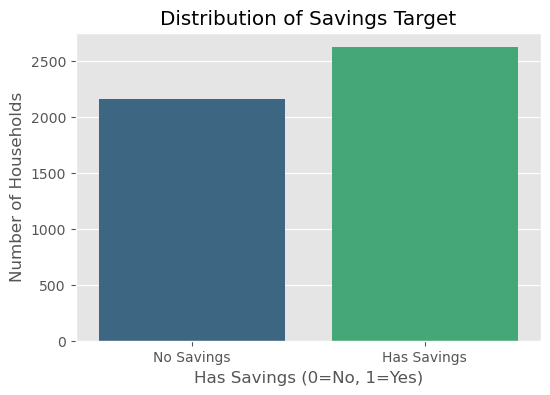

In [5]:
# Target distribution
target_counts = df['savings_target'].value_counts()
target_pct = df['savings_target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct
})

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='savings_target', palette='viridis')
plt.title('Distribution of Savings Target')
plt.xlabel('Has Savings (0=No, 1=Yes)')
plt.ylabel('Number of Households')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

## Section 4: Demographic Analysis

Analyzing how demographic characteristics relate to savings behavior.

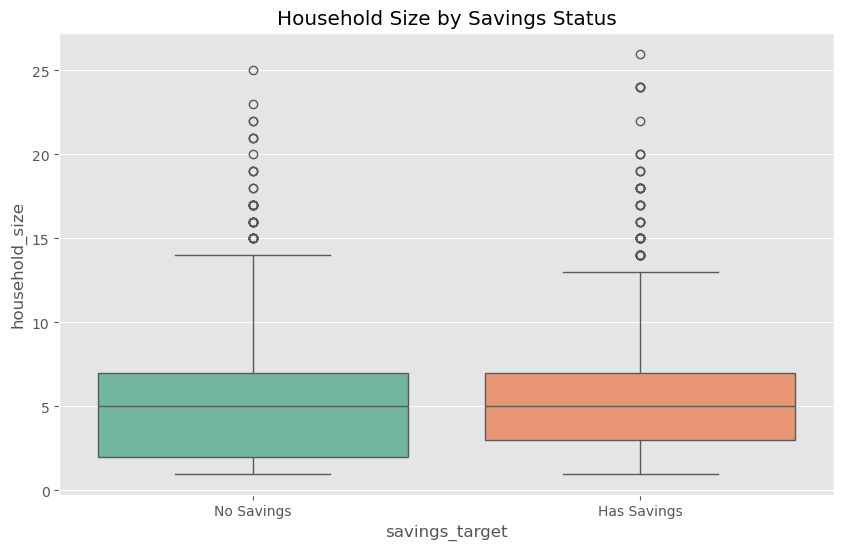

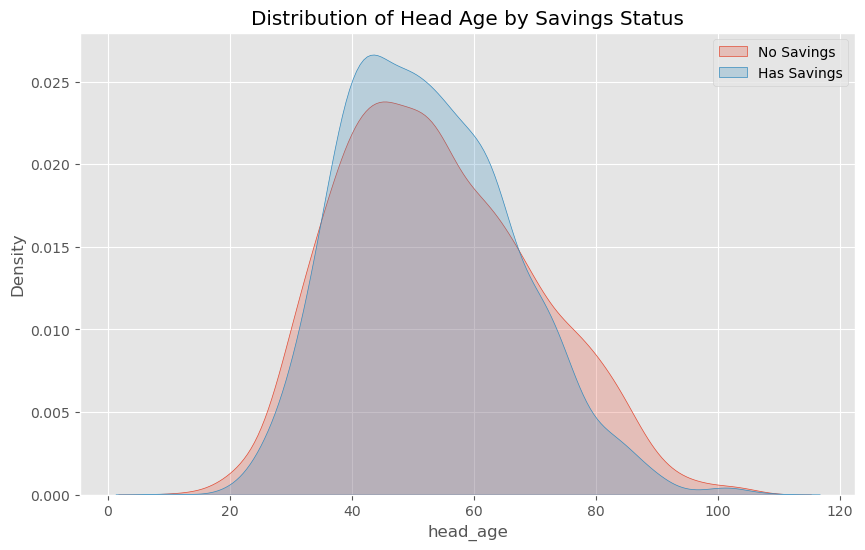

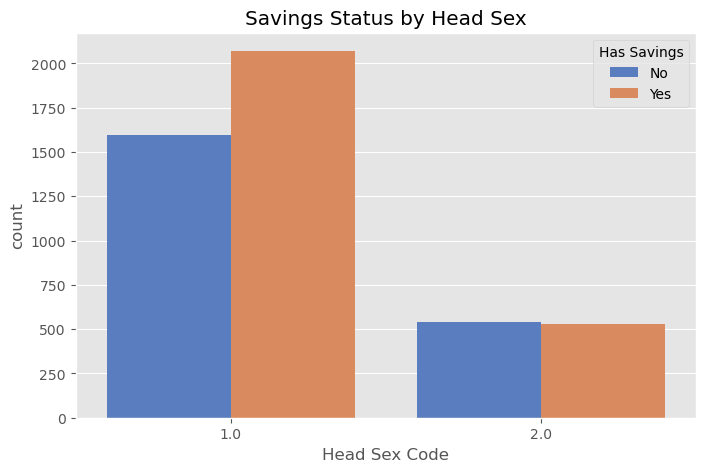

In [6]:
# 4.1 Household Size vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='household_size', palette='Set2')
plt.title('Household Size by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

# 4.2 Head Age vs Target
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['savings_target']==0], x='head_age', label='No Savings', shade=True)
sns.kdeplot(data=df[df['savings_target']==1], x='head_age', label='Has Savings', shade=True)
plt.title('Distribution of Head Age by Savings Status')
plt.legend()
plt.show()

# 4.3 Head Sex vs Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='head_sex_code', hue='savings_target', palette='muted')
plt.title('Savings Status by Head Sex')
plt.xlabel('Head Sex Code')
plt.legend(title='Has Savings', labels=['No', 'Yes'])
plt.show()

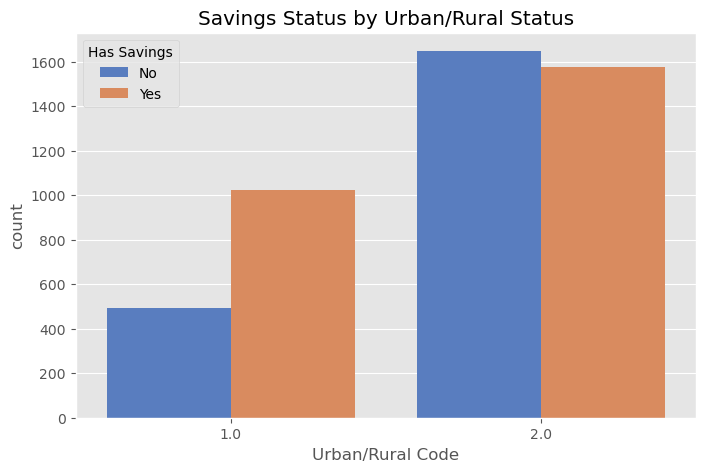

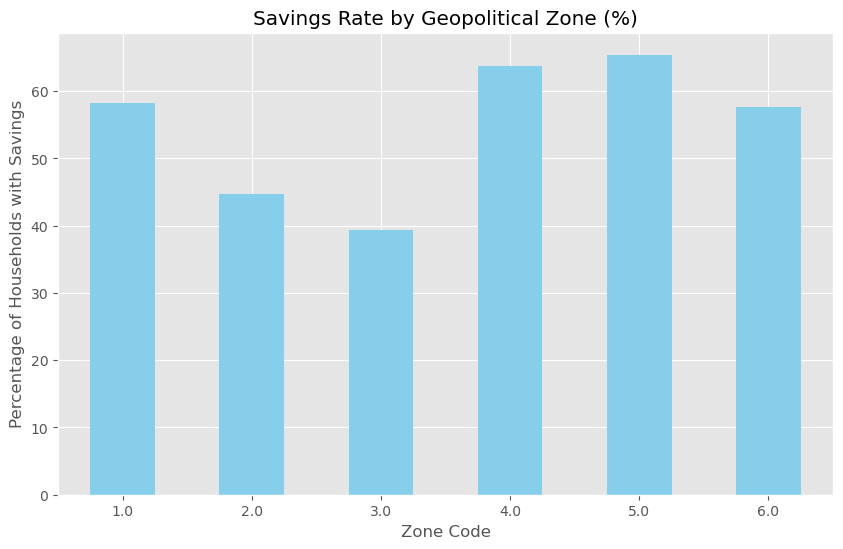

In [7]:
# 4.4 Urban/Rural vs Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='urban_rural_code', hue='savings_target', palette='muted')
plt.title('Savings Status by Urban/Rural Status')
plt.xlabel('Urban/Rural Code')
plt.legend(title='Has Savings', labels=['No', 'Yes'])
plt.show()

# 4.5 Geopolitical Zone vs Target
zone_savings = df.groupby('zone_code')['savings_target'].mean() * 100
plt.figure(figsize=(10, 6))
zone_savings.plot(kind='bar', color='skyblue')
plt.title('Savings Rate by Geopolitical Zone (%)')
plt.ylabel('Percentage of Households with Savings')
plt.xlabel('Zone Code')
plt.xticks(rotation=0)
plt.show()

## Section 5: Economic & Employment Analysis

Analyzing employment and income variables and their relationship with savings.

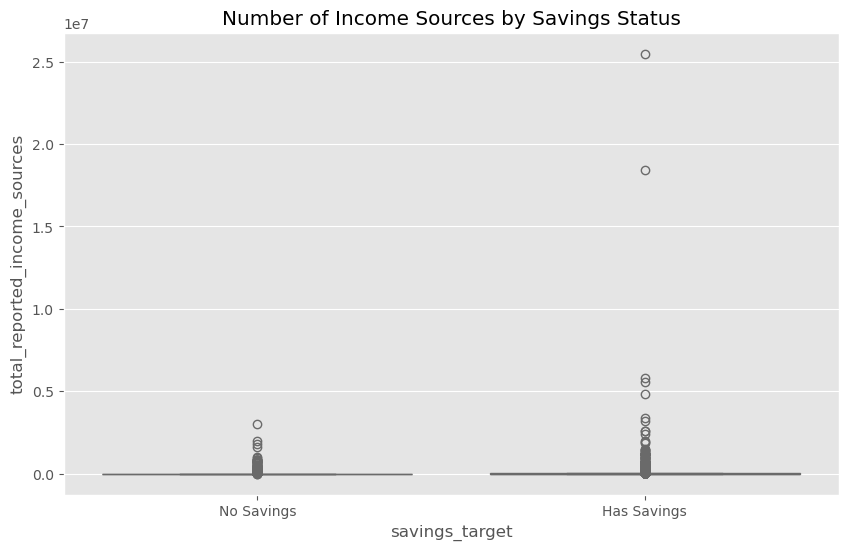

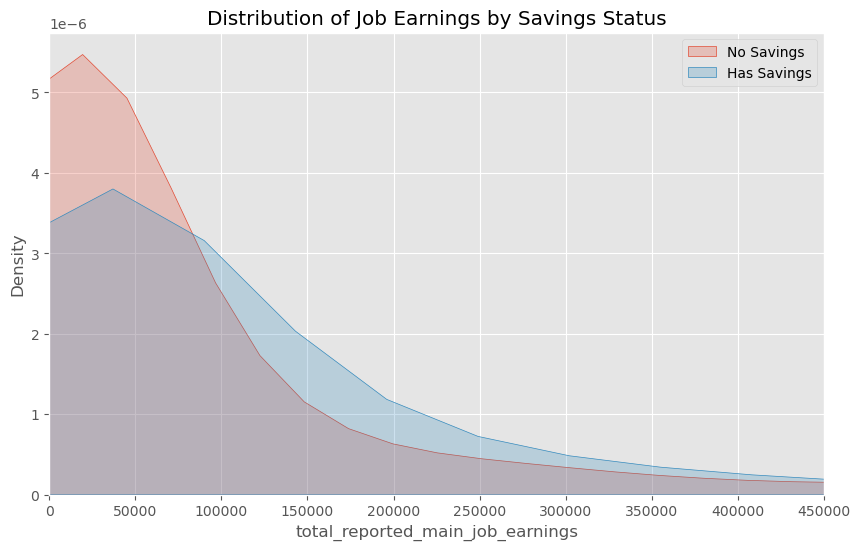

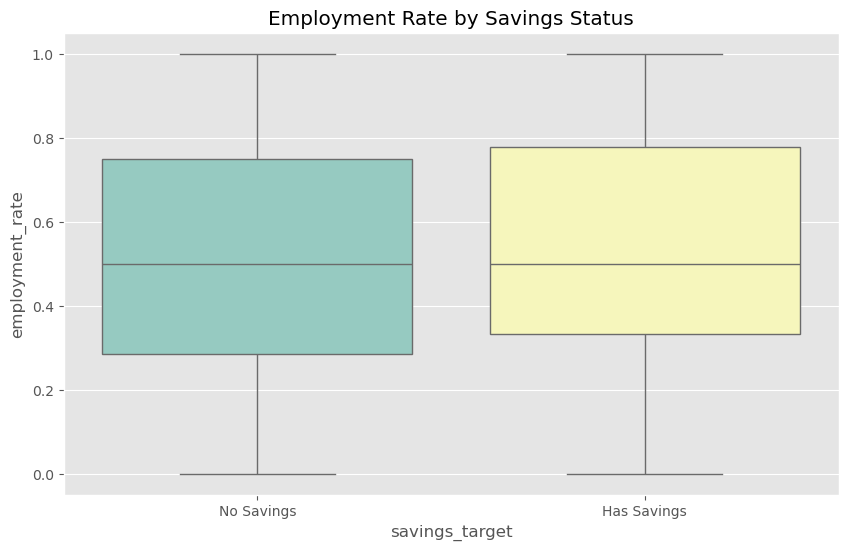

In [8]:
# 5.1 Income Sources vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='total_reported_income_sources', palette='Set3')
plt.title('Number of Income Sources by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

# 5.2 Earnings vs Target
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['savings_target']==0], x='total_reported_main_job_earnings', label='No Savings', shade=True)
sns.kdeplot(data=df[df['savings_target']==1], x='total_reported_main_job_earnings', label='Has Savings', shade=True)
plt.title('Distribution of Job Earnings by Savings Status')
plt.xlim(0, df['total_reported_main_job_earnings'].quantile(0.95)) # Clip for better visibility
plt.legend()
plt.show()

# 5.3 Employment Rate vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='employment_rate', palette='Set3')
plt.title('Employment Rate by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

## Section 6: Asset Analysis

Investigating the relationship between household assets and savings.

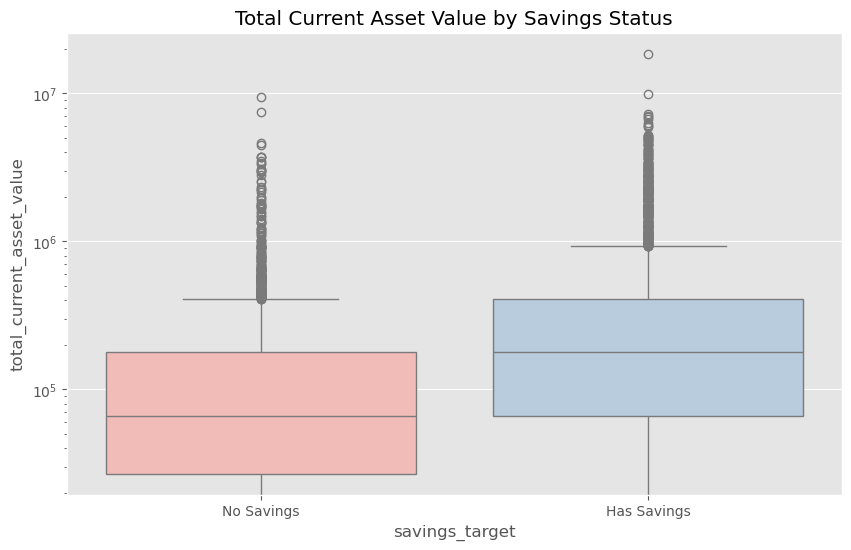

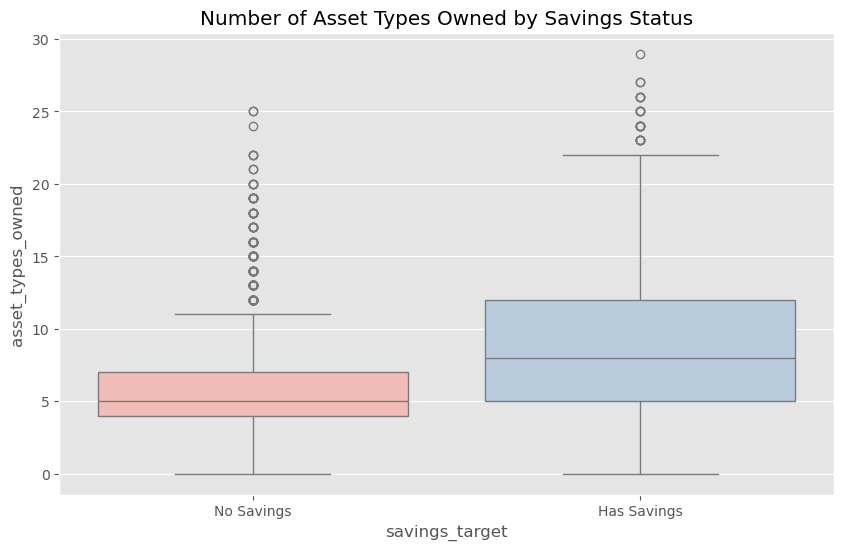

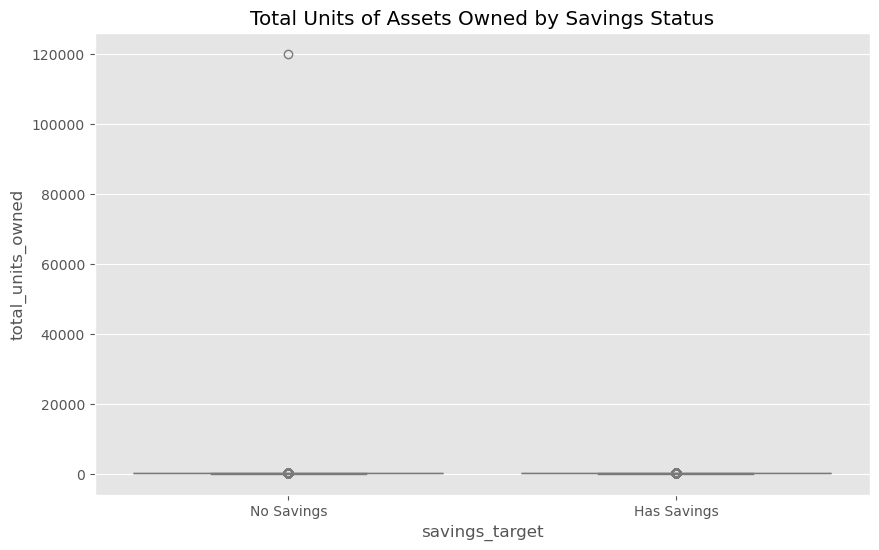

In [9]:
# 6.1 Total Asset Value vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='total_current_asset_value', palette='Pastel1')
plt.title('Total Current Asset Value by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.yscale('log') # Log scale due to expected skewness
plt.show()

# 6.2 Asset Types Owned vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='asset_types_owned', palette='Pastel1')
plt.title('Number of Asset Types Owned by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

# 6.3 Total Units Owned vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='savings_target', y='total_units_owned', palette='Pastel1')
plt.title('Total Units of Assets Owned by Savings Status')
plt.xticks([0, 1], ['No Savings', 'Has Savings'])
plt.show()

## Section 7: Financial Access Analysis

This section focuses on the relationship between financial institution access and savings, central to the financial inclusion objective.

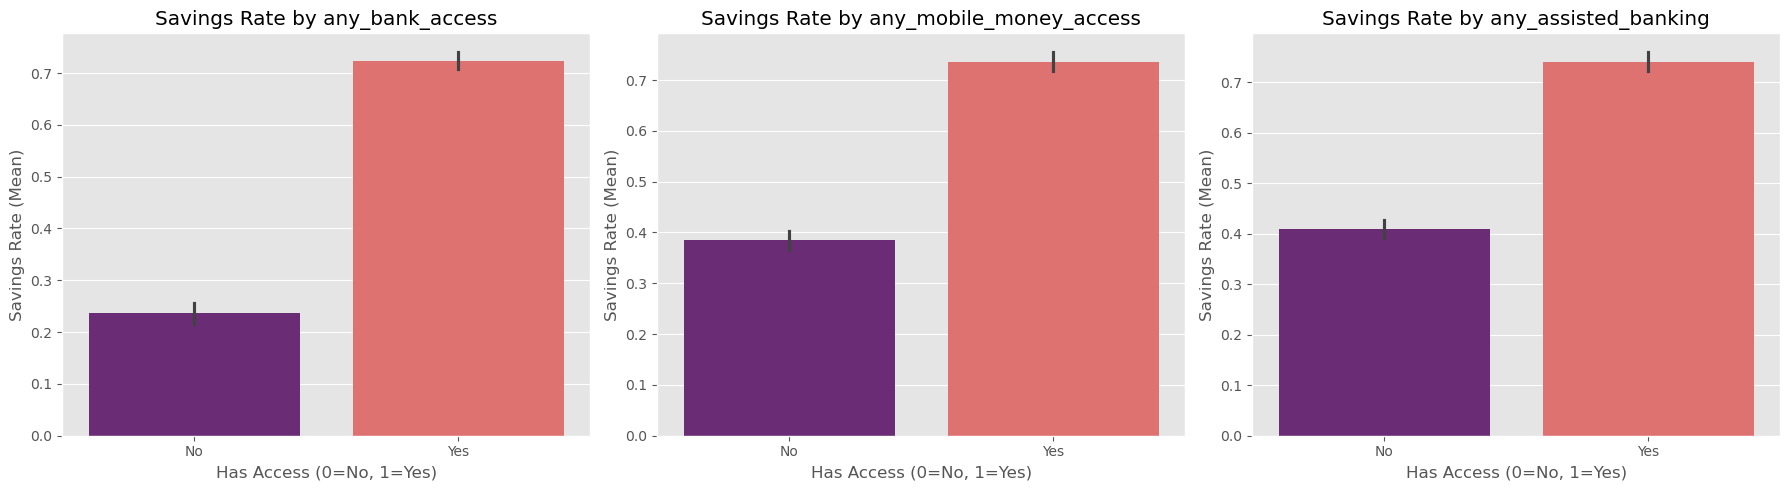

In [10]:
# 7.1 Bank Access vs Target
access_vars = ['any_bank_access', 'any_mobile_money_access', 'any_assisted_banking']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(access_vars):
    sns.barplot(data=df, x=var, y='savings_target', ax=axes[i], palette='magma')
    axes[i].set_title(f'Savings Rate by {var}')
    axes[i].set_ylabel('Savings Rate (Mean)')
    axes[i].set_xlabel('Has Access (0=No, 1=Yes)')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

## Section 8: Digital Access Analysis

Analyzing the correlation between digital tools (mobile/internet) and savings.

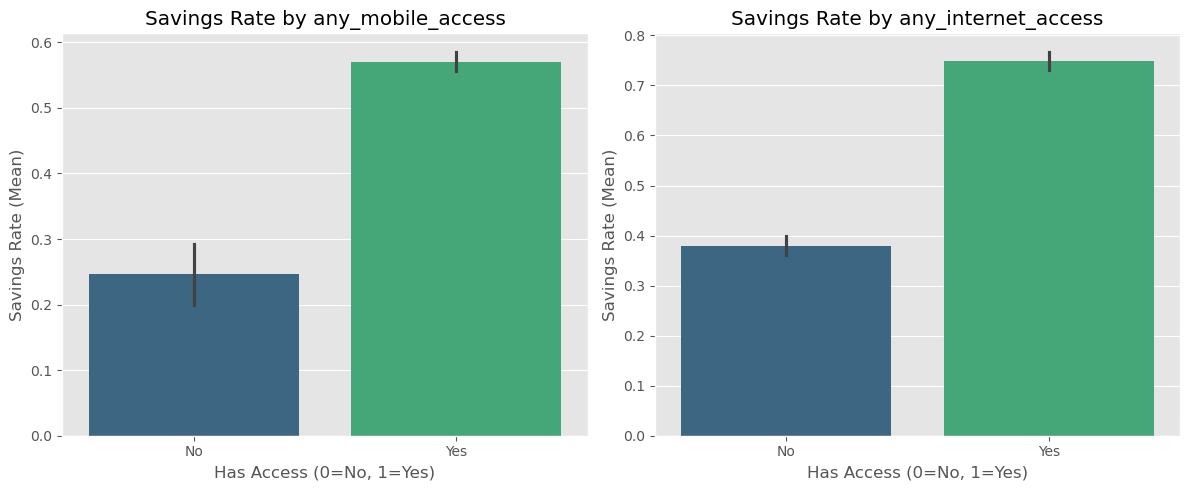

In [11]:
# Digital Access vs Target
digital_vars = ['any_mobile_access', 'any_internet_access']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(digital_vars):
    sns.barplot(data=df, x=var, y='savings_target', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Savings Rate by {var}')
    axes[i].set_ylabel('Savings Rate (Mean)')
    axes[i].set_xlabel('Has Access (0=No, 1=Yes)')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

## Section 9: Correlation Analysis

Evaluating numerical correlations to identify strong predictors and potential multicollinearity.

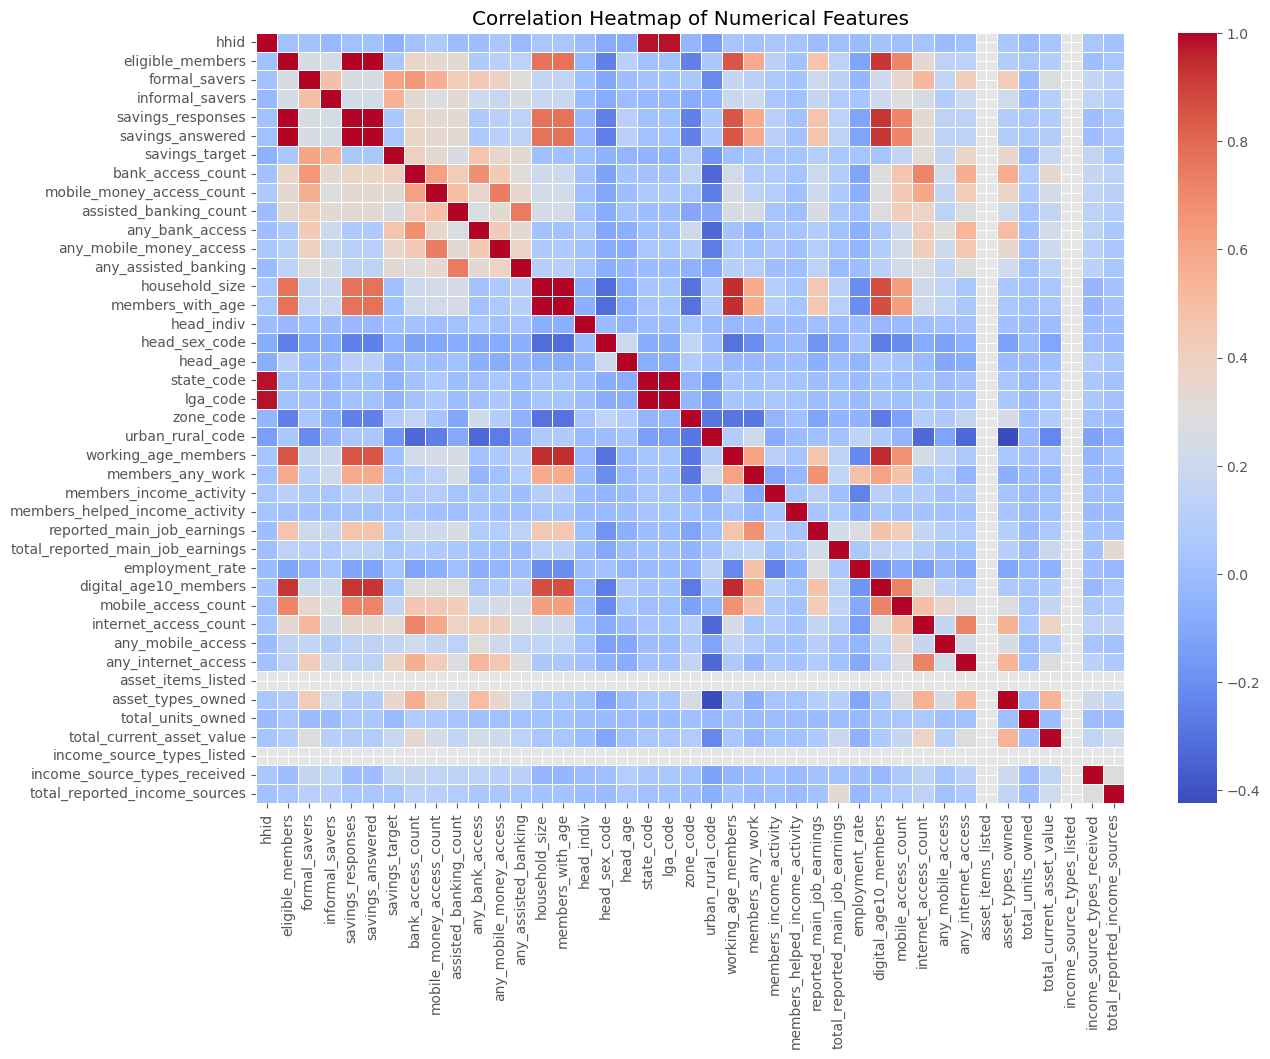

Top Correlations with savings_target:


savings_target                      1.000000
formal_savers                       0.604120
informal_savers                     0.553237
any_bank_access                     0.469002
bank_access_count                   0.401132
any_internet_access                 0.370137
any_mobile_money_access             0.352893
asset_types_owned                   0.344419
any_assisted_banking                0.328084
mobile_money_access_count           0.327269
internet_access_count               0.320382
assisted_banking_count              0.265166
total_current_asset_value           0.178818
any_mobile_access                   0.163216
mobile_access_count                 0.163020
income_source_types_received        0.153621
reported_main_job_earnings          0.101495
zone_code                           0.080278
savings_responses                   0.058196
eligible_members                    0.058196
savings_answered                    0.058101
total_reported_income_sources       0.050339
total_repo

In [12]:
# Calculate correlation matrix for numerical features
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Top correlations with savings_target
print("Top Correlations with savings_target:")
display(corr_matrix['savings_target'].sort_values(ascending=False))

## Section 10: Outliers and Distribution Analysis

Identifying skewed variables and extreme values that might affect model performance.

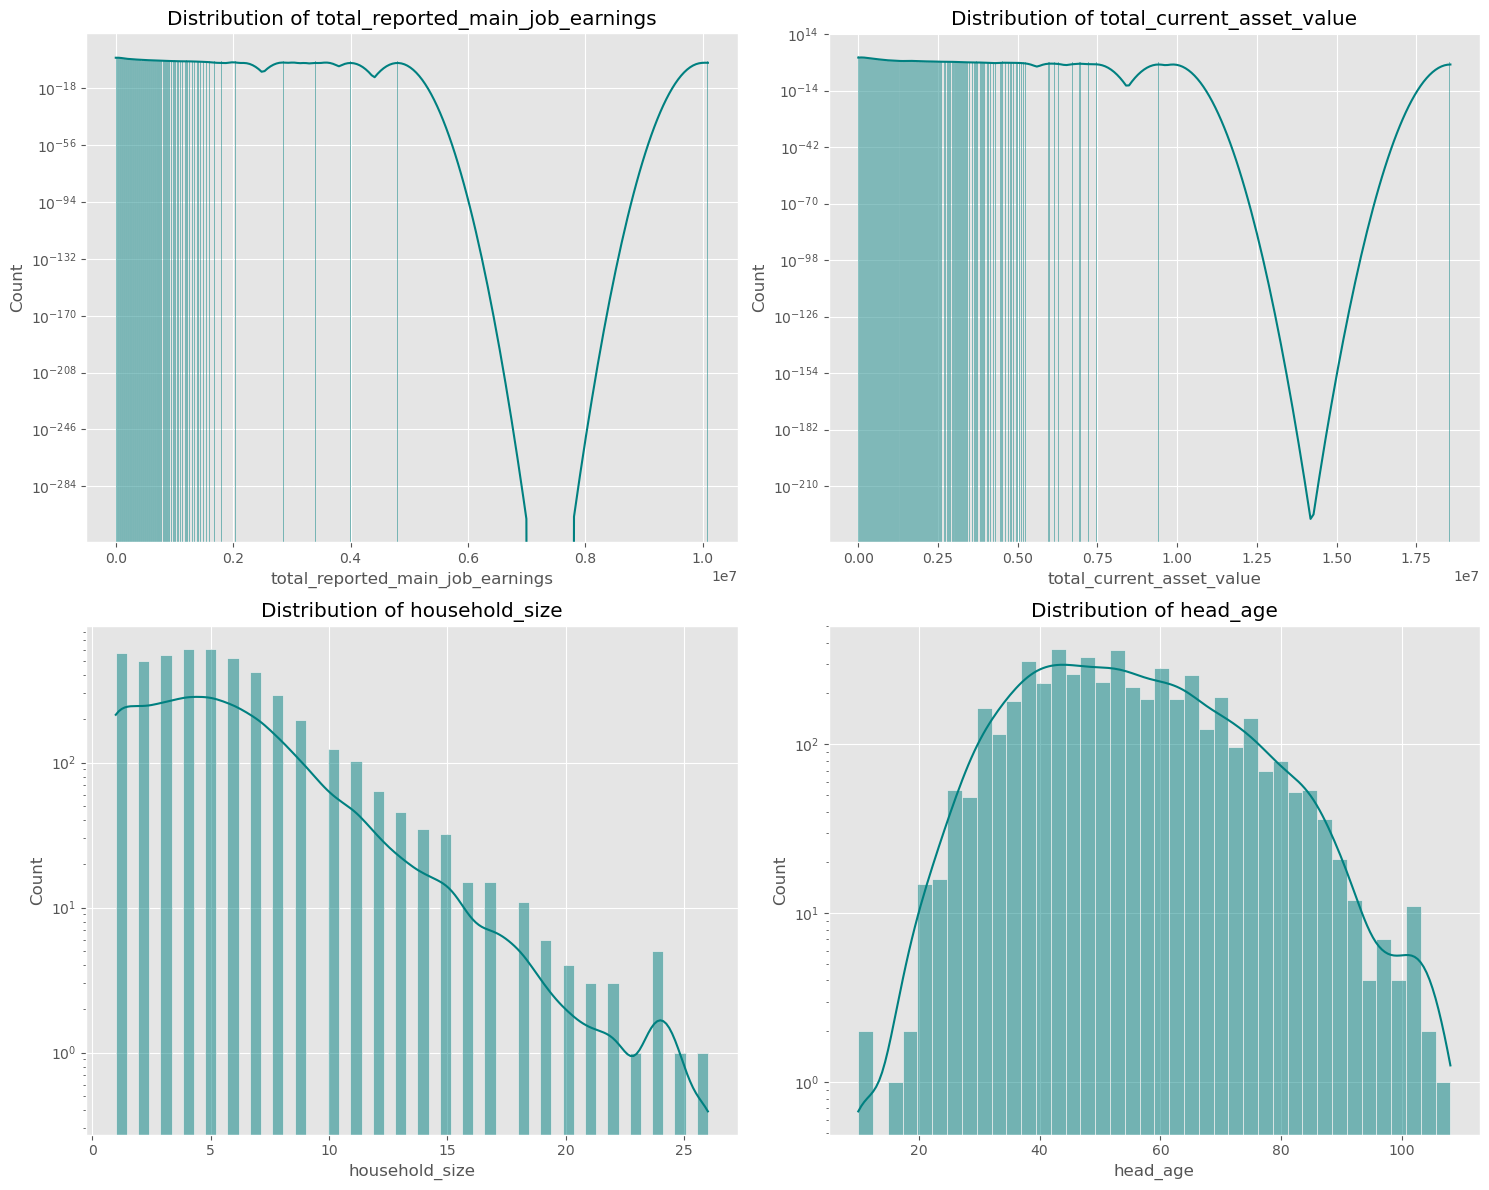

In [13]:
# Variables to check for skewness
skew_vars = ['total_reported_main_job_earnings', 'total_current_asset_value', 'household_size', 'head_age']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(skew_vars):
    sns.histplot(df[var], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_yscale('log') # Log scale to handle extreme skew

plt.tight_layout()
plt.show()

## Section 11: Feature Quality Check

Classifying variables for the ML stage.

In [14]:
# Classification of features
keep = [
    'household_size', 'head_age', 'head_sex_code', 'urban_rural_code', 'zone_code', 
    'working_age_members', 'members_any_work', 'members_income_activity', 
    'total_reported_main_job_earnings', 'employment_rate', 'total_reported_income_sources', 
    'asset_items_listed', 'asset_types_owned', 'total_units_owned', 'total_current_asset_value', 
    'any_bank_access', 'any_mobile_money_access', 'any_assisted_banking', 
    'any_mobile_access', 'any_internet_access'
]

transform = [
    'total_reported_main_job_earnings', 'total_current_asset_value', 'household_size'
]

drop = [
    'hhid', 'eligible_members', 'formal_savers', 'informal_savers', 'savings_responses', 
    'savings_answered', 'bank_access_count', 'mobile_money_access_count', 
    'assisted_banking_count', 'members_with_age', 'head_indiv', 'state_code', 
    'lga_code', 'state_name'
]

print(f"Keep: {len(keep)} features")
print(f"Transform: {len(transform)} features")
print(f"Drop: {len(drop)} features")

# Quick check to ensure all columns are accounted for
all_cols = set(df.columns)
accounted = set(keep + transform + drop)
missing = all_cols - accounted

if missing:
    print(f"Missing columns from classification: {missing}")
else:
    print("All columns classified.")

Keep: 20 features
Transform: 3 features
Drop: 14 features
Missing columns from classification: {'savings_target', 'mobile_access_count', 'members_helped_income_activity', 'income_source_types_listed', 'digital_age10_members', 'reported_main_job_earnings', 'internet_access_count', 'income_source_types_received'}


## Section 12: Final Summary & Next Steps

Summary of findings and implications for the machine learning pipeline.

In [15]:
# Summary Table
summary_data = {
    'Finding': [
        'Target distribution',
        'Missing data',
        'Age distribution',
        'Income skewness',
        'Financial access',
        'Asset values',
        'Categorical variables',
        'Correlated predictors'
    ],
    'Evidence': [
        'Check target_summary for distribution',
        'Check missing_df for gaps',
        'Check Age vs Target plot',
        'Check Earnings distribution plot',
        'Check Financial Access plot',
        'Check Asset Value plot',
        'State, Zone, Sex, Urban/Rural codes',
        'Check correlation heatmap'
    ],
    'Implication for ML': [
        'Consider F1-score/ROC-AUC if imbalanced',
        'Imputation strategy needed (median/mode)',
        'Scaling or binning may be required',
        'Log transformation recommended',
        'High importance predictor candidate',
        'Scaling/Outlier handling required',
        'One-hot or Label encoding needed',
        'Check multicollinearity for LogReg'
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\nRecommended Preprocessing Plan:")
print("1. Handle missing values (median for numerical, mode for categorical).")
print("2. Transform highly skewed numerical features (log transform).")
print("3. Encode categorical features (One-Hot Encoding for State/Zone).")
print("4. Scale numerical features (StandardScaler).")
print("5. Perform Train/Test split (stratified).")
print("6. Proceed to model training.")

,Finding,Evidence,Implication for ML
0,Target distribution,Check target_summary for distribution,Consider F1-score/ROC-AUC if imbalanced
1,Missing data,Check missing_df for gaps,Imputation strategy needed (median/mode)
2,Age distribution,Check Age vs Target plot,Scaling or binning may be required
3,Income skewness,Check Earnings distribution plot,Log transformation recommended
4,Financial access,Check Financial Access plot,High importance predictor candidate
5,Asset values,Check Asset Value plot,Scaling/Outlier handling required
6,Categorical variables,"State, Zone, Sex, Urban/Rural codes",One-hot or Label encoding needed
7,Correlated predictors,Check correlation heatmap,Check multicollinearity for LogReg



Recommended Preprocessing Plan:
1. Handle missing values (median for numerical, mode for categorical).
2. Transform highly skewed numerical features (log transform).
3. Encode categorical features (One-Hot Encoding for State/Zone).
4. Scale numerical features (StandardScaler).
5. Perform Train/Test split (stratified).
6. Proceed to model training.
